In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState


In [3]:
from langchain.chat_models import init_chat_model

In [4]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,  model_provider="google_vertexai")

In [5]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])
    return state

In [6]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm", call_model)
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)
graph = graph_builder.compile()

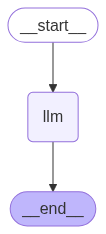

In [7]:
from utils import draw_graph
draw_graph(graph)


In [8]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [
    SystemMessage("You are an helpful assistant"),
    HumanMessage("I would like to know about democracy")

]
result = graph.invoke({"messages": messages})

In [9]:
result['messages']


[SystemMessage(content='You are an helpful assistant', additional_kwargs={}, response_metadata={}, id='c13faad8-f919-4b31-814f-b583d4287a6f'),
 HumanMessage(content='I would like to know about democracy', additional_kwargs={}, response_metadata={}, id='aff0e87e-03a0-4ae8-b8d0-a526e0a74526'),
 AIMessage(content='Democracy is a fascinating and profoundly important concept! At its heart, it\'s a system of government where the **people hold the power**.\n\nLet\'s break it down:\n\n---\n\n### I. Etymology & Core Definition\n\n*   **Origin:** The word "democracy" comes from two Greek words:\n    *   **"Demos"** meaning "people"\n    *   **"Kratos"** meaning "power" or "rule"\n*   **Definition:** Therefore, democracy literally means "rule by the people." In a democratic system, the supreme power is vested in the people and exercised by them either directly or indirectly through a system of representation, usually involving periodically held free elections.\n\n---\n\n### II. Historical Roots\n

In [10]:
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an helpful assistant
================================ Human Message =================================

I would like to know about democracy
================================== Ai Message ==================================

Democracy is a fascinating and profoundly important concept! At its heart, it's a system of government where the **people hold the power**.

Let's break it down:

---

### I. Etymology & Core Definition

*   **Origin:** The word "democracy" comes from two Greek words:
    *   **"Demos"** meaning "people"
    *   **"Kratos"** meaning "power" or "rule"
*   **Definition:** Therefore, democracy literally means "rule by the people." In a democratic system, the supreme power is vested in the people and exercised by them either directly or indirectly through a system of representation, usually involving periodically held free elections.

---

### II. Historical Roots

*   **Ancient Gree

In [11]:
from IPython.display import Markdown
Markdown(result['messages'][-1].content)

Democracy is a fascinating and profoundly important concept! At its heart, it's a system of government where the **people hold the power**.

Let's break it down:

---

### I. Etymology & Core Definition

*   **Origin:** The word "democracy" comes from two Greek words:
    *   **"Demos"** meaning "people"
    *   **"Kratos"** meaning "power" or "rule"
*   **Definition:** Therefore, democracy literally means "rule by the people." In a democratic system, the supreme power is vested in the people and exercised by them either directly or indirectly through a system of representation, usually involving periodically held free elections.

---

### II. Historical Roots

*   **Ancient Greece (Athens, 5th Century BCE):** Often credited as the birthplace of democracy. Athenian democracy was a *direct democracy*, where eligible male citizens directly participated in decision-making in the assembly.
*   **Roman Republic:** While not a full democracy, Rome's republican system with elected officials and a system of laws influenced later democratic thought.
*   **The Enlightenment (17th & 18th Centuries):** Philosophers like John Locke, Jean-Jacques Rousseau, and Montesquieu developed ideas about natural rights, the social contract, separation of powers, and popular sovereignty, which laid the intellectual groundwork for modern democracies.
*   **American and French Revolutions (late 18th Century):** These revolutionary movements put Enlightenment ideals into practice, leading to the establishment of republics based on the consent of the governed.

---

### III. Key Principles & Characteristics

While there's no single perfect model, most modern democracies share several core characteristics:

1.  **Rule of Law:** Everyone, including those in power, is subject to and accountable under the law. Laws are transparent, equally enforced, and independently adjudicated.
2.  **Human Rights & Civil Liberties:** Fundamental rights such as freedom of speech, assembly, religion, press, and the right to a fair trial are protected and guaranteed for all citizens.
3.  **Free and Fair Elections:** Citizens have the right to choose their representatives through regular, competitive, and transparent elections with universal suffrage (the right to vote for all adult citizens).
4.  **Separation of Powers:** Government power is typically divided among different branches (e.g., legislative, executive, judicial) to prevent the concentration of power and provide checks and balances.
5.  **Accountability & Transparency:** Government officials are accountable to the people, and government operations are open to public scrutiny.
6.  **Citizen Participation:** Active engagement of citizens in public life, beyond just voting, through protest, advocacy, civic groups, and informed debate.
7.  **Protection of Minorities:** While democracy is often about majority rule, a crucial aspect is the protection of the rights of minority groups to ensure they are not oppressed or excluded.

---

### IV. Types of Democracy

*   **Direct Democracy:** Citizens directly participate in decision-making (e.g., referendums, initiatives). Practical for small communities, but challenging for large nations.
*   **Representative Democracy (Republic):** Citizens elect representatives to make decisions on their behalf. This is the most common form today.
    *   **Parliamentary Democracy:** The executive branch (Prime Minister and cabinet) is drawn from and accountable to the legislative branch (parliament) (e.g., UK, Germany, Canada).
    *   **Presidential Democracy:** The executive branch (President) is elected independently of the legislative branch and is not directly accountable to it (e.g., USA, Brazil).
    *   **Semi-Presidential Democracy:** Blends elements of both parliamentary and presidential systems, with both a president and a prime minister (e.g., France, Russia).
*   **Constitutional Democracy:** A system in which the powers of government are defined and limited by a constitution, which protects individual rights. (Often overlaps with representative democracy).
*   **Social Democracy:** A political, social, and economic philosophy that combines democratic political governance with a socialist economic system. It typically advocates for universal social welfare programs and wealth redistribution, within a capitalist framework (e.g., Nordic countries).

---

### V. Advantages of Democracy

*   **Legitimacy:** Government derives its authority from the consent of the governed, making it more stable.
*   **Protection of Rights:** Designed to safeguard individual liberties and prevent tyranny.
*   **Accountability:** Leaders are accountable to the people and can be removed through elections.
*   **Peaceful Transition of Power:** Elections provide a structured and generally peaceful way to transfer power.
*   **Responsiveness:** Governments are theoretically more responsive to the needs and wishes of their citizens.
*   **Innovation & Self-Correction:** Free exchange of ideas and the ability to change policies based on public discourse fosters progress and allows for correction of mistakes.

---

### VI. Challenges & Criticisms

*   **Slow Decision-Making:** Deliberation, compromise, and checks and balances can make decision-making slow.
*   **"Tyranny of the Majority":** The potential for the majority to impose its will in a way that infringes upon the rights or interests of minorities.
*   **Voter Apathy & Low Participation:** If citizens don't engage, the system loses its democratic legitimacy.
*   **Misinformation & Polarization:** In the digital age, the spread of false information and increasing political polarization can undermine reasoned public discourse.
*   **Influence of Special Interests:** Wealthy individuals or powerful lobby groups can exert undue influence on policy-making.
*   **Inequality:** Economic inequality can translate into political inequality, undermining the principle of one person, one vote.
*   **Populism:** The rise of populist leaders who bypass traditional institutions and appeal directly to popular sentiment can pose a challenge to democratic norms.

---

### Conclusion

Democracy is not a static state but a continuous process. It requires constant vigilance, active participation, and a commitment from its citizens and institutions to uphold its principles. It's an ideal that many societies strive for, recognizing its potential for fostering freedom, justice, and the well-being of all its people.

In [12]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [SystemMessage("you are and helpful assistant"),
            HumanMessage("what is langgraph")]

In [14]:
#synchronous
for chunk in graph.stream({"messages": messages},stream_mode="updates"):
    print(chunk)


{'llm': {'messages': AIMessage(content='**LangGraph is an extension of the LangChain framework, specifically designed for building robust, stateful, and cyclic multi-actor applications with Large Language Models (LLMs).**\n\nThink of it as a way to define complex, interactive workflows where an AI (or multiple AIs, or an AI interacting with tools and humans) can make decisions, perform actions, and then loop back to previous steps or try alternative paths based on the outcome.\n\nHere\'s a breakdown of what that means and why it\'s powerful:\n\n### The Problem LangGraph Solves\n\nTraditional LangChain "chains" are often linear or directed acyclic graphs (DAGs). This means they have a clear start and end, and the execution flows in one direction without looping back. While powerful for many tasks, this structure struggles with:\n\n1.  **Complex Agentic Behavior:** When an AI needs to iteratively refine an answer, retry a tool, perform multiple steps to achieve a goal, or engage in a mul

In [16]:
#async
async for chunk in graph.astream({"messages": messages}, stream_mode="updates"):
    print(chunk)

{'llm': {'messages': AIMessage(content='**LangGraph is an extension of LangChain designed specifically for building stateful, multi-actor applications with Large Language Models (LLMs) by representing their logic as a graph.**\n\nThink of it this way:\n\n*   **LangChain** is excellent for creating linear sequences of LLM calls, tool uses, and data transformations (e.g., "Take user input, pass to LLM, use tool, return result"). These are often called "chains."\n*   **LangGraph** takes this a significant step further by allowing you to define complex, cyclic workflows. It enables you to build "agentic systems" where an LLM (or multiple LLMs/agents) can make decisions, use tools, get feedback, and then decide what to do next, potentially looping back to previous steps, or branching based on conditions.\n\nHere\'s a breakdown of its core concepts and why it\'s powerful:\n\n### Core Concepts of LangGraph\n\n1.  **Nodes:**\n    *   Each node in the graph represents a specific step or action.

In [17]:

# synchronous
llm.invoke(messages)

AIMessage(content='**LangGraph is a library built on top of LangChain, specifically designed for building robust, stateful, and cyclic multi-actor applications with Large Language Models (LLMs).**\n\nThink of it as a specialized framework within the LangChain ecosystem that allows you to define complex, dynamic workflows that can "loop back" and manage shared state, which is crucial for advanced LLM agents and multi-step processes.\n\nHere\'s a breakdown of what that means and why it\'s important:\n\n### Why LangGraph? The Problem It Solves\n\nLangChain is excellent for building sequential "chains" of operations (e.g., "prompt LLM -> parse output -> call tool"). However, many advanced LLM applications, especially autonomous agents, require more sophisticated control flow:\n\n1.  **State Management:** An agent needs to remember what happened in previous steps, its observations, and its plan.\n2.  **Conditional Logic:** The next action depends on the outcome of the current action (e.g., 

In [18]:
# async
async for chunk in llm.astream(messages):
    print(chunk)

content='LangGraph is an extension of the LangChain framework that is specifically designed for building **stateful' additional_kwargs={} response_metadata={'safety_ratings': [], 'usage_metadata': {}} id='run--ffd3e0d1-9f16-4c29-8ab0-d391c18e908c'
content=", multi-actor applications** using a **graph-based approach**.\n\nIn simpler terms, while traditional LangChain chains are often linear (input -> process -> output), LangGraph allows you to define complex, cyclical workflows, making it ideal for building more robust and intelligent AI agents.\n\nHere's a breakdown of what that" additional_kwargs={} response_metadata={'safety_ratings': [], 'usage_metadata': {}} id='run--ffd3e0d1-9f16-4c29-8ab0-d391c18e908c'
content=" means and why it's powerful:\n\n### The Problem LangGraph Solves\n\nStandard AI agents often struggle with:\n1.  **State Management:** How does an agent remember what happened in previous steps or turns?\n2.  **Complex Control Flow:** How do you enable an agent to decide 

In [19]:
async for chunk in llm.astream(messages):
    if chunk.content:
        print(chunk.content)

LangGraph is an extension of the LangChain framework that is specifically designed for building **stateful, multi-actor applications with LLMs**, especially those that require **complex, cyclical
, and dynamic execution flows**.

Think of it as a way to define and manage a "finite state machine" for your LLM applications, where the "states" are different actions or steps, and the "transitions" between states can be determined dynamically by an LLM or other logic.

Here's a
 breakdown of what LangGraph is, why it's needed, and its core concepts:

---

### The Problem LangGraph Solves

Traditional LangChain "chains" are great for sequential processes (e.g., retrieve, then augment, then generate). However, many complex LLM applications, particularly sophisticated agents,
 require:

1.  **Non-linear execution:** The next step isn't always fixed. It might depend on the output of the previous step, user input, or external tool results.
2.  **Cycles/Loops:** Agents often need to "think," "sel

In [20]:
#synchronous
for chunk in graph.stream({"messages": messages},stream_mode="updates"):
    print(chunk)

{'llm': {'messages': AIMessage(content='**LangGraph** is an extension of the LangChain framework, specifically designed for building **stateful, multi-actor applications** using a **graph-based approach**.\n\nThink of it as a powerful orchestration layer on top of LangChain\'s existing components (like LLMs, tools, and runnables).\n\nHere\'s a breakdown of what that means:\n\n1.  **Graph-Based Approach:**\n    *   **Nodes:** These represent individual steps or components in your application. A node could be:\n        *   An LLM call (e.g., generating a response).\n        *   A tool call (e.g., searching the web, calling an API, querying a database).\n        *   A custom Python function (e.g., parsing data, making a decision).\n        *   Human intervention (e.g., asking for user confirmation).\n    *   **Edges:** These define the transitions between nodes. Edges can be:\n        *   **Conditional:** The next node to execute depends on the output or state of the current node. This is

In [21]:
messages

[SystemMessage(content='you are and helpful assistant', additional_kwargs={}, response_metadata={}, id='fed00768-8efe-4e03-a803-27bc8cb72783'),
 HumanMessage(content='what is langgraph', additional_kwargs={}, response_metadata={}, id='8125558e-2685-4347-bf0c-ae65c809a1fe')]